<a href="https://colab.research.google.com/github/emilyperras/econ5200-final-project/blob/main/notebooks/econ5200_senate_trading_proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project April 19th Checkpoint
## Emily Perras - Analysis of Stock Returns by Political Party
Should the Stock Act (April 2014) Be Revised?

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [23]:
!pip install -q kagglehub
!pip install -q yfinance

# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
# from doubleml import DoubleMLPLR, DoubleMLData

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
## Part 1: Executive Summary (Not Relevant For Initial Checkpoint)

Use SCR (Situation – Complication – Resolution) structure. Fill this in LAST, after your analysis is complete.

> **We estimate that [treatment] has an effect of [X] on [outcome] (95% CI: [a, b]).**
>
> **Situation:** ___
> **Complication:** ___
> **Resolution:** ___
>
> **We recommend [action] because [reason].**
>
> **Key assumption that could invalidate this:** ___

---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does party affiliation (Republican vs. Democrat) cause higher excess stock trading returns relative to the S&P 500?
- **Identification strategy:** Double Machine Learning (DML).
- **Key assumption:** Conditional independence, after controlling for when senators traded (Time Fixed Effects) and how active they were (senator trade volume), party affiliation is unrelated to any remaining factor that drives excess returns above the S&P. The only reason one party would have systematically higher excess returns than the other, when timing and activity are accounted for, is the result of something party itself causes, such as committee assignments and the legislative information that comes with them. The most plausible violation of this assumption is committee assignments, which correlate with party but are not directly observed in this dataset.
- **Treatment variable:** Political Party, Republican = 1, Democrat = 0
Outcome: Direction-adjusted 30-day excess return vs SPY
- **Outcome variable:** Direction-adjusted 30-day excess return vs S&P 500 (SPY)
- **Controls:** Year fixed effects, party affiliation, senator trade volume, purchase/sale flag
- **Why prediction alone is insufficient:** A prediction model would help us identify which senators have higher returns however we want to understand if party affiliation causes abnormal stock returns. Running a DML model will help us sepparate the cofounders like trading volume so we can understand how party differences affect stock trading philosophy, reflected by returns.

**Dataset:** Senate STOCK Act disclosures — Kaggle (`heresjohnnyv/congress-investments`, CC0 Public Domain)  
**N:** ~12,000 stock trades across 54 senators, 2014–2021  
**Key limitation:** Only electronically filed trades are captured. PDF/handwritten submissions and trades in tickers without Yahoo Finance data are excluded, Only caputuring the 250 most traded stocks by volume

In [24]:
# --- Data Loading ---
import kagglehub
path = kagglehub.dataset_download("heresjohnnyv/congress-investments")
print("Path:", path)
import os
os.listdir(path)
df = pd.read_csv(path + "/SenatorCleaned.csv")
df.head()

Using Colab cache for faster access to the 'congress-investments' dataset.
Path: /kaggle/input/congress-investments


,Unnamed: 0,Name,Transaction.Date,Owner,Ticker,Asset.Name,Asset.Type,Type,Amount,Comment
0,1,Sheldon Whitehouse,11/25/2014,Self,M,"Macy's, Inc. (NYSE)",Stock,Purchase,1001.0,--
1,2,Sheldon Whitehouse,12/18/2014,Self,BEAV,B/E Aerospace Inc. (NASDAQ),Stock,Sale (Full),15001.0,--
2,3,Sheldon Whitehouse,12/18/2014,Self,KORS,Michael Kors Holdings Limited (NYSE),Stock,Sale (Partial),1001.0,--
3,4,Sheldon Whitehouse,12/18/2014,Self,T,"AT&T, Inc. (NYSE)",Stock,Purchase,1001.0,--
4,5,Sheldon Whitehouse,12/18/2014,Self,KEYS,"Keysight Technologies, Inc. (NYSE)",Stock,Sale (Full),1001.0,Agilent Tech common stock completed a spinoff ...


In [28]:
# --- EDA: Summary Statistics ---
df.describe(include='all')
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15666 entries, 0 to 15665
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        15666 non-null  int64  
 1   Name              15666 non-null  object 
 2   Transaction.Date  15666 non-null  object 
 3   Owner             15666 non-null  object 
 4   Ticker            15666 non-null  object 
 5   Asset.Name        15666 non-null  object 
 6   Asset.Type        14250 non-null  object 
 7   Type              15666 non-null  object 
 8   Amount            15665 non-null  float64
 9   Comment           15666 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.2+ MB


In [29]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nRows where Ticker == '--': {(df['Ticker'] == '--').sum()}")
print('These rows have no ticker and cannot be matched to price data — dropped in cleaning.')

            Missing Count  Missing %
Asset.Type           1416       9.04
Amount                  1       0.01

Rows where Ticker == '--': 1629
These rows have no ticker and cannot be matched to price data — dropped in cleaning.


In [33]:
stocks = df.copy()

# Keep only stock trades with valid tickers
stocks = stocks[stocks['Asset.Type'] == 'Stock']
stocks = stocks[stocks['Ticker'].notna() & (stocks['Ticker'] != '--')]
stocks = stocks[stocks['Type'].isin(['Purchase', 'Sale (Full)', 'Sale (Partial)'])]
stocks = stocks[stocks['Transaction.Date'].notna()].copy()

# Convert 'Transaction.Date' to datetime format
stocks['Transaction.Date'] = pd.to_datetime(stocks['Transaction.Date'], errors='coerce')
stocks['year'] = stocks['Transaction.Date'].dt.year

# Drop pre-2014: the STOCK Act created the disclosure requirement in 2012
# so only 13 stock trades exist before 2014 — not enough for analysis
stocks = stocks[stocks['year'] >= 2014].copy()

print(f'Cleaned sample: {stocks.shape[0]} trades')
print(f'Years: {stocks["year"].min()} – {stocks["year"].max()}')
print(f'Senators: {stocks["Name"].nunique()}')
print(f'\nTrades by year:')
print(stocks['year'].value_counts().sort_index())

Cleaned sample: 12246 trades
Years: 2014 – 2021
Senators: 53

Trades by year:
year
2014    3951
2015    1641
2016    1176
2017    1550
2018    1534
2019     719
2020    1486
2021     189
Name: count, dtype: int64


In [34]:
len(stocks["Name"].unique())
sorted(stocks["Name"].unique())

[' A. Mitchell McConnell Jr.',
 ' Angus S King Jr.',
 ' Benjamin L Cardin',
 ' Chris Van Hollen',
 ' Christopher A Coons',
 ' Claire McCaskill',
 ' Cory A Booker',
 ' Daniel R Coats',
 ' Daniel S Sullivan',
 ' David A Perdue Jr',
 ' David B Vitter',
 ' Dean Heller',
 ' Gary C Peters',
 ' Jacklyn S Rosen',
 ' James M Inhofe',
 ' Jeffry L Flake',
 ' Jerry Moran',
 ' John Cornyn',
 ' John D Rockefeller IV',
 ' John F Reed',
 ' John Hoeven',
 ' John N Kennedy',
 ' John W Hickenlooper',
 ' Jon Kyl',
 ' Joseph Manchin III',
 ' Kelly Loeffler',
 ' Ladda Tammy Duckworth',
 ' Maria Cantwell',
 ' Mark Begich',
 ' Mark R Warner',
 ' Michael B Enzi',
 ' Michael F Bennet',
 ' Pat Roberts',
 ' Patrick J Toomey',
 ' Patty Murray',
 ' Rafael E Cruz',
 ' Rand Paul',
 ' Robert P Casey Jr.',
 ' Robert P Corker Jr.',
 ' Roy Blunt',
 ' Sheldon Whitehouse',
 ' Shelley M Capito',
 ' Susan M Collins',
 ' Thad Cochran',
 ' Thomas H Tuberville',
 ' Thomas R Carper',
 ' Thomas R Tillis',
 ' Thomas Udall',
 ' Tim

In [36]:
# CSV has leading spaces on names
stocks['Name'] = stocks['Name'].str.strip()

# --- Party mapping (verified from public congressional records) ---
# Treatment variable: 0 = Democrat, 1 = Republican
party_map = {
    'A. Mitchell McConnell Jr.': 1, 'Angus S King Jr.': 2,
    'Barbara A Mikulski': 0, 'Barbara Boxer': 0,
    'Benjamin L Cardin': 0, 'Chris Van Hollen': 0,
    'Christopher A Coons': 0, 'Claire McCaskill': 0,
    'Cory A Booker': 0, 'Daniel R Coats': 1,
    'Daniel S Sullivan': 1, 'David A Perdue Jr': 1,
    'David B Vitter': 1, 'Dean Heller': 1,
    'Gary C Peters': 0, 'Harry Reid': 0,
    'Heidi Heitkamp': 0, 'Jacklyn S Rosen': 0,
    'James M Inhofe': 1, 'Jeanne Shaheen': 0,
    'Jefferson B Sessions III': 1, 'Jeffry L Flake': 1,
    'Jerry Moran': 1, 'John A Barrasso': 1,
    'John Cornyn': 1, 'John D Rockefeller IV': 0,
    'John F Reed': 0, 'John Hoeven': 1,
    'John McCain': 1, 'John N Kennedy': 1,
    'John W Hickenlooper': 0, 'Jon Kyl': 1,
    'Joseph Manchin III': 0, 'Joseph S Donnelly': 0,
    'Kelly Loeffler': 1, 'Ladda Tammy Duckworth': 0,
    'Lamar Alexander': 1, 'Luther J Strange III': 1,
    'Maria Cantwell': 0, 'Mark Begich': 0,
    'Mark E Udall': 0, 'Mark R Warner': 0,
    'Michael B Enzi': 1, 'Michael D Crapo': 1,
    'Michael F Bennet': 0, 'Mike Rounds': 1,
    'Orrin G Hatch': 1, 'Pat Roberts': 1,
    'Patrick J Toomey': 1, 'Patty Murray': 0,
    'Rafael E Cruz': 1, 'Rand Paul': 1,
    'Rick Scott': 1, 'Robert J Portman': 1,
    'Robert P Casey Jr.': 0, 'Robert P Corker Jr.': 1,
    'Roger W Marshall': 1, 'Ron Johnson': 1,
    'Roy Blunt': 1, 'Saxby Chambliss': 1,
    'Sheldon Whitehouse': 0, 'Shelley M Capito': 1,
    'Steve Daines': 1, 'Susan M Collins': 1,
    'Thad Cochran': 1, 'Thomas H Tuberville': 1,
    'Thomas R Carper': 0, 'Thomas R Tillis': 1,
    'Thomas Udall': 0, 'Timothy M Kaine': 0,
    'Tina Smith': 0, 'Tom Coburn': 1,
    'William Cassidy': 1, 'William F Hagerty IV': 1
}

stocks['party'] = stocks['Name'].map(party_map)
stocks['party_label'] = stocks['party'].map(
    {0: 'Democrat', 1: 'Republican', 2: 'Independent'}
)

unmapped = stocks[stocks['party'].isna()]['Name'].unique()
if len(unmapped):
    print(f'WARNING — unmapped senators: {unmapped}')
else:
    print('All senators successfully mapped to party.')

# Restrict to Republican vs Democrat only for the causal comparison
stocks_rd = stocks[stocks['party'].isin([0, 1])].copy()
print(f'\nR vs D sample: {stocks_rd.shape[0]} trades')
print(stocks_rd['party_label'].value_counts())

All senators successfully mapped to party.

R vs D sample: 12215 trades
party_label
Republican    10574
Democrat       1641
Name: count, dtype: int64


In [37]:
import yfinance as yf

# Use all R vs D trades for the analysis
trades = stocks_rd[stocks_rd['Transaction.Date'].notna()].copy()

# Top 250 most-traded tickers keeps download runtime manageable
# while covering the bulk of trading activity
top_tickers = trades['Ticker'].value_counts().head(250).index.tolist()

start_date = trades['Transaction.Date'].min() - pd.Timedelta(days=10)
end_date   = trades['Transaction.Date'].max() + pd.Timedelta(days=45)

print(f'Tickers to download: {len(top_tickers)}')
print(f'Date range: {start_date.date()} to {end_date.date()}')

Tickers to download: 250
Date range: 2013-12-29 to 2021-09-13


In [38]:
price_data  = {}
bad_tickers = []

for ticker in top_tickers:
    try:
        hist = yf.download(
            ticker,
            start=start_date.strftime('%Y-%m-%d'),
            end=end_date.strftime('%Y-%m-%d'),
            auto_adjust=True, progress=False, threads=False
        )
        if hist.empty:
            bad_tickers.append(ticker); continue
        temp = hist[['Close']].reset_index()
        temp.columns = ['Date', 'Close']
        temp['Ticker'] = ticker
        price_data[ticker] = temp
    except:
        bad_tickers.append(ticker)

print(f'Successfully downloaded: {len(price_data)} tickers')
print(f'Failed: {len(bad_tickers)} tickers')

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DISCA']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FEYE']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CBS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['WPX']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FDC']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FB']: YFPricesMissingError('possibly delisted; no price data found  (1d 2013-12-29 -> 2021-09-13) (Yahoo error = "Data doesn\'t exist for startDate = 1388293200, endDate = 1631505600")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['AAN']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['WFM']: YFP

Successfully downloaded: 202 tickers
Failed: 48 tickers


In [40]:
prices = pd.concat(price_data.values(), ignore_index=True)
prices['Date'] = pd.to_datetime(prices['Date'])
prices = prices.sort_values(['Ticker', 'Date']).reset_index(drop=True)

trades_sub = trades[trades['Ticker'].isin(price_data.keys())].copy()
print(f'Trades with price data: {trades_sub.shape[0]} of {trades.shape[0]}')

Trades with price data: 6680 of 12215


In [41]:
prices_s = prices.sort_values(['Date', 'Ticker']).reset_index(drop=True)
trades_s  = trades_sub.sort_values(['Transaction.Date', 'Ticker']).reset_index(drop=True)

#Match each trade to its entry price
#direction='forward' handles weekends/holidays by taking next available close
entry = pd.merge_asof(
    trades_s, prices_s,
    left_on='Transaction.Date', right_on='Date',
    by='Ticker', direction='forward'
).rename(columns={'Date': 'entry_date', 'Close': 'entry_price'})

entry['target_date_30'] = entry['Transaction.Date'] + pd.Timedelta(days=30)

#match to exit price 30 days later
future_30 = pd.merge_asof(
    entry.sort_values(['target_date_30', 'Ticker']).reset_index(drop=True),
    prices_s,
    left_on='target_date_30', right_on='Date',
    by='Ticker', direction='forward'
).rename(columns={'Date': 'exit_date_30', 'Close': 'exit_price_30'})

future_30['return_30d'] = (
    (future_30['exit_price_30'] - future_30['entry_price'])
    / future_30['entry_price']
)
print(future_30[['Ticker','Type','entry_price','exit_price_30','return_30d']].head(6))

  Ticker      Type  entry_price  exit_price_30  return_30d
0   AAPL  Purchase    16.841007      16.200493   -0.038033
1   AAPL  Purchase    16.841007      16.200493   -0.038033
2   AAPL  Purchase    16.841007      16.200493   -0.038033
3   AAPL  Purchase    16.841007      16.200493   -0.038033
4   AAPL  Purchase    16.841007      16.200493   -0.038033
5   AAPL  Purchase    16.841007      16.200493   -0.038033


Directional Adjustments for Buying and Selling

In [44]:
# Download SPY benchmark
spy = yf.download('SPY', start='2013-01-01', end='2022-01-01',
                   auto_adjust=True, progress=False, threads=False)
spy = spy[['Close']].reset_index()
spy.columns = ['Date', 'Close']
spy['Date'] = pd.to_datetime(spy['Date'])
spy = spy.sort_values('Date').reset_index(drop=True)

#match SPY entry price to each trade date
future_30 = future_30.sort_values('Transaction.Date').reset_index(drop=True)
future_30 = pd.merge_asof(
    future_30,
    spy.rename(columns={'Date': 'spy_entry_date', 'Close': 'spy_entry_price'}),
    left_on='Transaction.Date', right_on='spy_entry_date', direction='forward')

#Match SPY exit price to each 30-day target
future_30 = future_30.sort_values('target_date_30').reset_index(drop=True)
future_30 = pd.merge_asof(
    future_30,
    spy.rename(columns={'Date': 'spy_exit_date', 'Close': 'spy_exit_price_30'}),
    left_on='target_date_30', right_on='spy_exit_date', direction='forward')

#SPY return over the exact same 30-day window as each trade
future_30['spy_return_30d'] = (
    (future_30['spy_exit_price_30']
     - future_30['spy_entry_price'])
    / future_30['spy_entry_price'])

# Excess return: senator trade return minus SPY over the same window
future_30['excess_return_30d'] = (
    future_30['return_30d'] - future_30['spy_return_30d'])

# Direction-adjusted excess return — our main outcome variable
# PURCHASES: positive excess = senator bought before a stock ran up (good call)
# SALES: flip the sign — if stock dropped after they sold, that is also a good call
# Higher directional_excess always means more evidence of information advantage
future_30['directional_excess'] = np.where(
    future_30['Type'] == 'Purchase',
     future_30['excess_return_30d'],
    -future_30['excess_return_30d'])

# Drop rows missing price or SPY data
future_30 = future_30[
    future_30['spy_entry_price'].notna() &
    future_30['spy_exit_price_30'].notna() &
    future_30['directional_excess'].notna()].copy()

future_30['year'] = future_30['Transaction.Date'].dt.year

print(f'Final analysis sample: {future_30.shape[0]} trades')
print(future_30['party_label'].value_counts())

Final analysis sample: 6680 trades
party_label
Republican    5894
Democrat       786
Name: count, dtype: int64


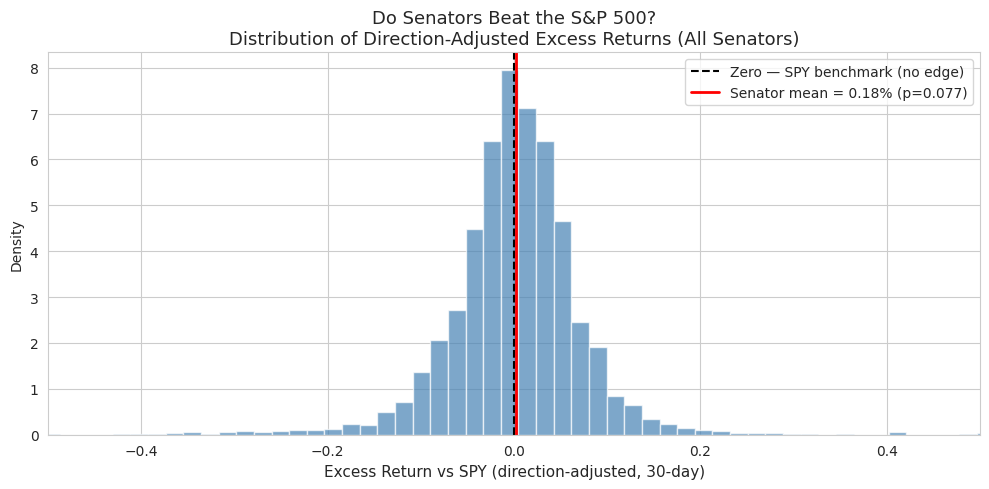

Mean excess return: 0.175%
T-stat vs zero: 1.769 | P-value: 0.0769

Interpretation: If the red line is to the right of zero and p < 0.05,
senators systematically beat SPY — motivating the party comparison.


In [45]:
# --- Visualization 1: Do senators beat SPY overall? ---
# This is our motivating result — if senators as a whole don't beat SPY,
# the party comparison is moot. We establish this first.

all_excess = future_30['directional_excess'].dropna()
mean_excess = all_excess.mean()
t_stat, p_val = stats.ttest_1samp(all_excess, 0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_excess, bins=80, color='steelblue', alpha=0.7,
        density=True, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1.5,
           label='Zero — SPY benchmark (no edge)')
ax.axvline(mean_excess, color='red', linestyle='-', linewidth=2,
           label=f'Senator mean = {mean_excess*100:.2f}% (p={p_val:.3f})')
ax.set_title(
    'Do Senators Beat the S&P 500?\n'
    'Distribution of Direction-Adjusted Excess Returns (All Senators)',
    fontsize=13
)
ax.set_xlabel('Excess Return vs SPY (direction-adjusted, 30-day)', fontsize=11)
ax.set_ylabel('Density')
ax.set_xlim(-0.5, 0.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Mean excess return: {mean_excess*100:.3f}%')
print(f'T-stat vs zero: {t_stat:.3f} | P-value: {p_val:.4f}')
print()
print('Interpretation: If the red line is to the right of zero and p < 0.05,')
print('senators systematically beat SPY, motivating the party comparison.')

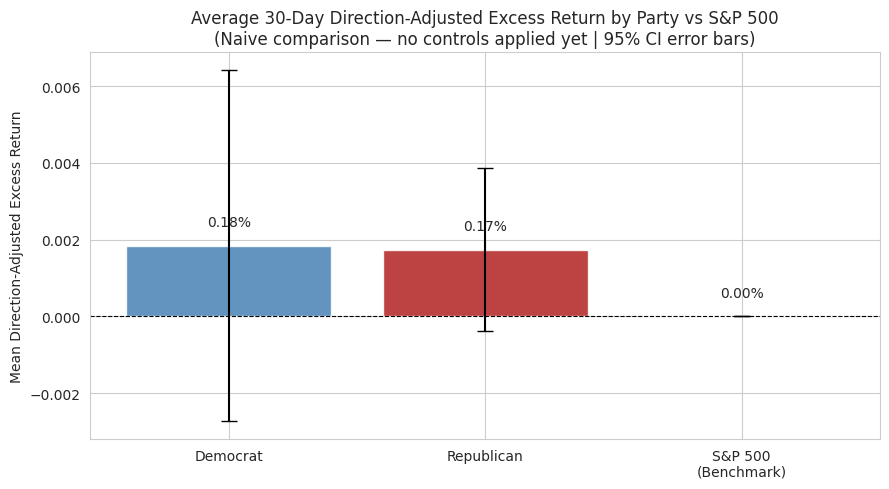

               mean     sem  count
party_label                       
Democrat     0.0018  0.0023    786
Republican   0.0017  0.0011   5894

Interpretation: This is the NAIVE party comparison with no controls.
Any difference here may reflect year effects or activity differences,
not a true causal party effect. DML in Part 7 corrects for this.


In [46]:
# --- Visualization 2: Republican vs Democrat vs SPY ---
# The core party comparison. SPY = 0 is the natural benchmark for both groups.
# Error bars show 95% confidence intervals.

party_stats = future_30.groupby('party_label')['directional_excess'].agg(
    mean='mean', sem='sem', count='count'
)

fig, ax = plt.subplots(figsize=(9, 5))
labels = list(party_stats.index) + ['S&P 500\n(Benchmark)']
means  = list(party_stats['mean']) + [0.0]
errors = list(party_stats['sem'] * 1.96) + [0.0]
colors = ['steelblue', 'firebrick', 'gray']

bars = ax.bar(labels, means, yerr=errors, color=colors,
              capsize=6, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(
    'Average 30-Day Direction-Adjusted Excess Return by Party vs S&P 500\n'
    '(Naive comparison — no controls applied yet | 95% CI error bars)',
    fontsize=12
)
ax.set_ylabel('Mean Direction-Adjusted Excess Return')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{val*100:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(party_stats.round(4))
print()
print('Interpretation: This is the NAIVE party comparison with no controls.')
print('Any difference here may reflect year effects or activity differences,')
print('not a true causal party effect. DML in Part 7 corrects for this.')

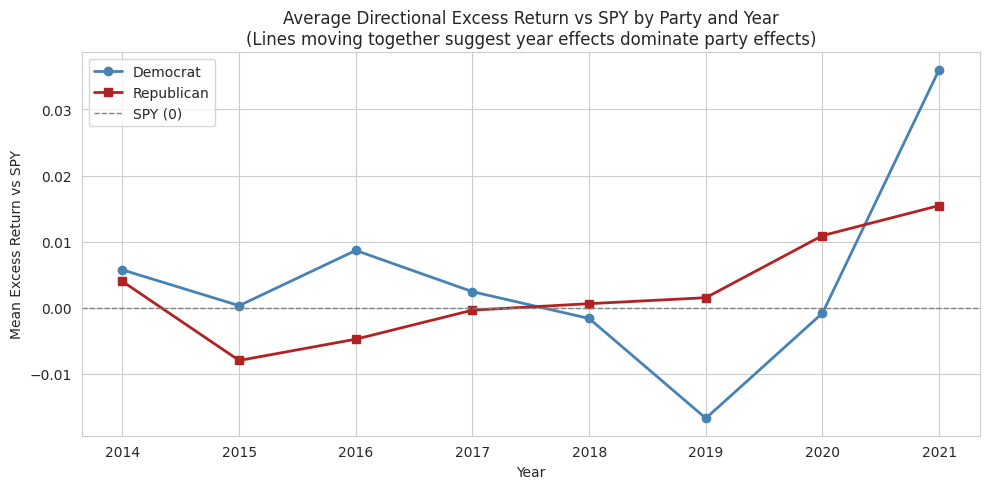

Interpretation: Lines moving in parallel suggest both parties are exposed
to the same market conditions each year — justifying year fixed effects as
a control. A persistent gap between the lines across all years would suggest
a genuine party-driven information advantage.


In [47]:
# --- Visualization 3: Party performance vs SPY over time ---
# Did Republicans and Democrats beat the market in the same years?
# If lines move together, year effects explain the variation — not party.
# If one party consistently sits above the other across ALL years,
# that is stronger evidence of a genuine party difference.

party_year = (
    future_30.groupby(['year', 'party_label'])['directional_excess']
    .mean().unstack()
)

fig, ax = plt.subplots(figsize=(10, 5))
party_year['Democrat'].plot(ax=ax, marker='o', color='steelblue',
                             linewidth=2, label='Democrat')
party_year['Republican'].plot(ax=ax, marker='s', color='firebrick',
                               linewidth=2, label='Republican')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='SPY (0)')
ax.set_title(
    'Average Directional Excess Return vs SPY by Party and Year\n'
    '(Lines moving together suggest year effects dominate party effects)',
    fontsize=12
)
ax.set_ylabel('Mean Excess Return vs SPY')
ax.set_xlabel('Year')
ax.legend()
plt.tight_layout()
plt.show()

print('Interpretation: Lines moving in parallel suggest both parties are exposed')
print('to the same market conditions each year — justifying year fixed effects as')
print('a control. A persistent gap between the lines across all years would suggest')
print('a genuine party-driven information advantage.')

In [51]:
# --- EDA: Balance Check (treated vs. untreated) ---
print(future_30.groupby('party_label')[['directional_excess','return_30d']].agg(['count','mean','std']))
print(future_30.groupby(['party_label','year']).size().unstack(fill_value=0))

# Naive OLS: directional_excess ~ party (no controls)
y_naive = future_30['directional_excess'].values
X_naive = sm.add_constant(future_30['party'].values)

naive_model = sm.OLS(y_naive, X_naive).fit()
print(naive_model.summary())

naive_est = naive_model.params[1]
naive_ci  = naive_model.conf_int()[1]
print(f'\nNaive party effect (Republican minus Democrat): {naive_est*100:.3f}%')
print(f'95% CI: [{naive_ci[0]*100:.3f}%, {naive_ci[1]*100:.3f}%]')
print()
print('Expected bias: Year effects and senator activity level are not controlled.')
print('If Republicans dominate high-activity or high-volatility years, the naive')
print('estimate overstates the true causal party effect on excess returns.')

            directional_excess                     return_30d            \
                         count      mean       std      count      mean   
party_label                                                               
Democrat                   786  0.001844  0.065580        786  0.017563   
Republican                5894  0.001742  0.082854       5894  0.005697   

                       
                  std  
party_label            
Democrat     0.076789  
Republican   0.103887  
year         2014  2015  2016  2017  2018  2019  2020  2021
party_label                                                
Democrat      108   118   124   191   101    57    75    12
Republican   1909   648   555   657   836   428   826    35
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Lea

In [ ]:
# --- EDA: Treatment-Outcome Visualization ---
# fig, ax = plt.subplots()
# sns.boxplot(data=df, x=treatment_col, y='your_outcome', ax=ax)
# ax.set_title('Outcome by Treatment Status')
# plt.tight_layout()
# plt.show()

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [ ]:
# --- Naive OLS ---
# X_naive = df[['your_treatment']]
# X_naive = sm.add_constant(X_naive)
# y = df['your_outcome']
# naive_model = sm.OLS(y, X_naive).fit()
# print(naive_model.summary())
# naive_estimate = naive_model.params['your_treatment']
# naive_ci = naive_model.conf_int().loc['your_treatment'].values
# print(f'\nNaive estimate: {naive_estimate:.4f} (95% CI: [{naive_ci[0]:.4f}, {naive_ci[1]:.4f}])')

**Why the naive estimate is biased:** ___

### 3b. Causal Estimate

In [ ]:
# --- Causal Method: Double Machine Learning (example) ---
# from econml.dml import LinearDML
#
# Y = df['your_outcome'].values
# T = df['your_treatment'].values
# X = df[['control_1', 'control_2', 'control_3']].values  # effect modifiers (optional)
# W = df[['confounder_1', 'confounder_2']].values          # confounders
#
# dml = LinearDML(
#     model_y=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml.fit(Y, T, X=X, W=W)
#
# causal_estimate = dml.ate(X)
# causal_ci = dml.ate_interval(X, alpha=0.05)
# print(f'Causal ATE: {causal_estimate:.4f}')
# print(f'95% CI: [{causal_ci[0]:.4f}, {causal_ci[1]:.4f}]')

### 3c. Prediction Model (for comparison)

In [ ]:
# --- Predictive Model (NOT causal — for comparison only) ---
# from sklearn.metrics import r2_score, mean_squared_error
#
# all_features = ['your_treatment', 'control_1', 'control_2', 'confounder_1']
# rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
# y_pred = cross_val_predict(rf, df[all_features], df['your_outcome'], cv=5)
#
# print(f'Prediction R²: {r2_score(df["your_outcome"], y_pred):.3f}')
# print(f'Prediction RMSE: {np.sqrt(mean_squared_error(df["your_outcome"], y_pred)):.3f}')
# print('\nNote: This tells us how well we can PREDICT the outcome,')
# print('but NOT how the treatment CAUSES changes in the outcome.')

### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

In [ ]:
# --- Comparison Plot ---
# fig, ax = plt.subplots(figsize=(8, 5))
#
# estimates = ['Naive OLS', 'Causal (DML)']
# points = [naive_estimate, causal_estimate]
# ci_lower = [naive_ci[0], causal_ci[0]]
# ci_upper = [naive_ci[1], causal_ci[1]]
# errors = [[p - l for p, l in zip(points, ci_lower)],
#           [u - p for p, u in zip(points, ci_upper)]]
#
# ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=8,
#             markersize=10, linewidth=2, color='#1a237e')
# ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
# ax.set_ylabel('Estimated Effect')
# ax.set_title('Naive vs. Causal Estimate')
# plt.tight_layout()
# plt.show()

### 3e. Robustness Check

In [ ]:
# --- Robustness: Different nuisance model ---
# dml_robust = LinearDML(
#     model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
#     cv=5,
#     random_state=RANDOM_STATE
# )
# dml_robust.fit(Y, T, X=X, W=W)
# robust_ate = dml_robust.ate(X)
# robust_ci = dml_robust.ate_interval(X, alpha=0.05)
# print(f'Robustness ATE (RF nuisance): {robust_ate:.4f}')
# print(f'95% CI: [{robust_ci[0]:.4f}, {robust_ci[1]:.4f}]')

---
## Part 4: Threats to Identification

**Minimum 500 words. Be honest — this is where you demonstrate critical thinking.**

### 1. Most Serious Threat

- **Threat:** ___
- **Direction of bias:** [Does this make my estimate too large or too small?]
- **What would address it:** [Ideal data, instrument, or design]

### 2. Second Threat

- **Threat:** ___
- **Why it matters:** ___
- **Partial mitigation:** [What I did or could do]

### 3. What I Cannot Rule Out

[Be honest about what remains. This limitation means my estimate should be interpreted as ___ rather than a definitive causal effect.]

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [ ]:
# Save this as app.py in your project repo

streamlit_template = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="Consulting Report Dashboard", layout="wide")
st.title("Consulting Report: [Your Title]")

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1
)

# TODO: Add more sliders for your specific parameters
# control_level = st.sidebar.selectbox("Control scenario", ["Low", "Medium", "High"])

# --- Load your fitted model or pre-computed results ---
# Option 1: Load a pickled model
# import joblib
# model = joblib.load("fitted_model.pkl")

# Option 2: Use pre-computed coefficients
baseline_ate = 0.0    # TODO: Replace with your causal estimate
baseline_se = 0.0     # TODO: Replace with your standard error

# --- Compute What-If Estimate ---
adjusted_ate = baseline_ate * treatment_multiplier
adjusted_se = baseline_se * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se

# --- Display Results ---
col1, col2, col3 = st.columns(3)
col1.metric("Estimated Effect", f"{adjusted_ate:.3f}")
col2.metric("95% CI Lower", f"{ci_lower:.3f}")
col3.metric("95% CI Upper", f"{ci_upper:.3f}")

st.markdown(f"""
> **What-if interpretation:** If treatment intensity is multiplied by
> {treatment_multiplier:.1f}x, the estimated effect changes to
> {adjusted_ate:.3f} (95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]).
""")

# --- Uncertainty Visualization ---
multipliers = np.arange(0.5, 3.1, 0.1)
ates = baseline_ate * multipliers
ses = baseline_se * multipliers

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.2)", name="95% CI"
))
fig.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig.add_vline(x=treatment_multiplier, line_dash="dash", line_color="red",
              annotation_text=f"Current: {treatment_multiplier:.1f}x")
fig.update_layout(
    title="What-If: Effect vs. Treatment Intensity",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect",
    template="plotly_white"
)
st.plotly_chart(fig, use_container_width=True)

# --- Counterfactual Scenario ---
st.subheader("Counterfactual: What if treatment intensity doubled?")
counterfactual_ate = baseline_ate * 2.0
counterfactual_ci = (counterfactual_ate - 1.96 * baseline_se * 2.0,
                     counterfactual_ate + 1.96 * baseline_se * 2.0)
st.write(f"If treatment intensity doubled, the estimated effect would be "
         f"**{counterfactual_ate:.3f}** (95% CI: [{counterfactual_ci[0]:.3f}, {counterfactual_ci[1]:.3f}]).")
'''

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

---
## Part 6: Presentation Script

**5 minutes total. Practice with a timer.**

| Segment | Time | Your Script |
|---------|------|-------------|
| **Hook** | 30s | ___ |
| **Problem** | 60s | ___ |
| **Method** | 60s | ___ |
| **Finding** | 60s | ___ |
| **Recommendation** | 60s | ___ |
| **Defense** | 30s | ___ |

### Adversarial Prep

| Question Category | Your Prepared Answer |
|-------------------|---------------------|
| "How do you know this is causal?" | ___ |
| "Why this model?" | ___ |
| "Would this generalize?" | ___ |
| "Is the effect large enough?" | ___ |

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: [Task — e.g., Code Generation]

- **Prompt:** [What you asked the AI]
- **Response:** [Summary of what the AI produced]
- **Iterate:** [What you changed or asked to refine]
- **Modify:** [How you adapted the output for your specific use case]
- **Evaluate:** [How you verified correctness — tests run, sources checked, logic reviewed]

### Entry 2: [Task — e.g., Analysis Assistance]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___

### Entry 3: [Task — e.g., Writing / Literature Review]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___